# SHEETAL PATIL | ANIMAL CLASSIFICATION USING KNN

**About Dataset**

This dataset consists of 101 animals from a zoo.\
There are 16 variables with various traits to describe the animals.\
The 7 Class Types are: Mammal, Bird, Reptile, Fish, Amphibian, Bug and Invertebrate

The purpose for this dataset is to be able to predict the classification of the animals, based upon the variables.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

In [2]:
# Load the dataset
df = pd.read_csv('D:\\Work\\ExcelRCource\\Assignments\\16 KNN\\Zoo.csv')

In [3]:
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [6]:
df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [5]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


### Data Visualization

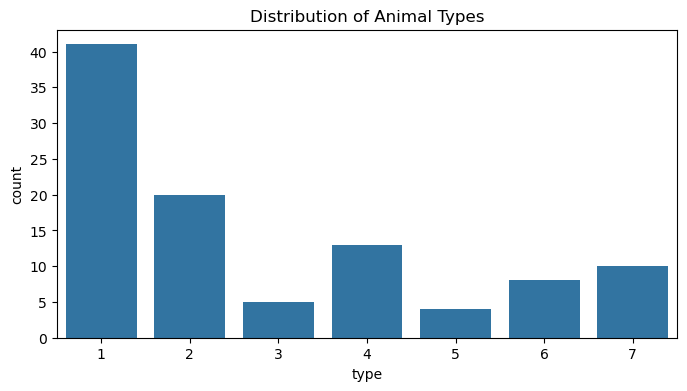

In [34]:
plt.figure(figsize=(8,4))
sns.countplot(x='type', data=df)
plt.title('Distribution of Animal Types')
plt.show()

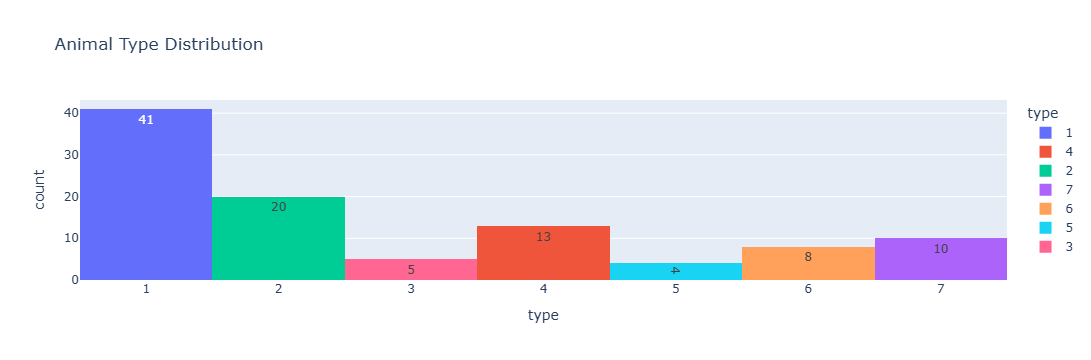

In [44]:
import plotly.express as px
fig = px.histogram(df, x='type', color='type', title="Animal Type Distribution", text_auto=True)
fig.show()

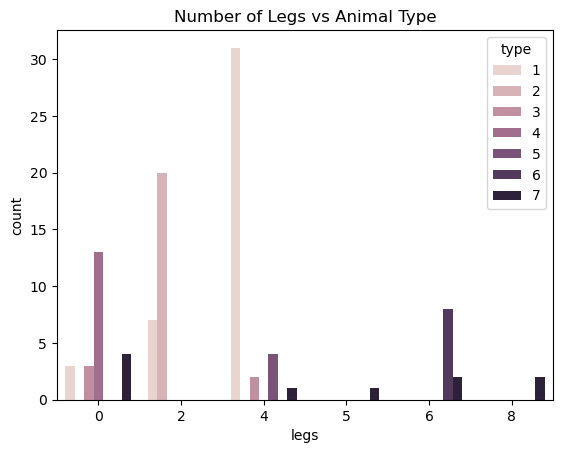

In [36]:
sns.countplot(x='legs', hue='type', data=df)
plt.title("Number of Legs vs Animal Type")
plt.show()

Animals with:\
2 legs → mostly birds\
4 legs → mammals/reptiles\
Strong classification feature

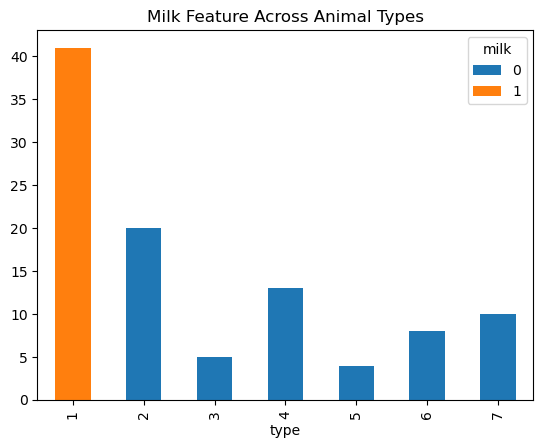

In [37]:
pd.crosstab(df['type'], df['milk']).plot(kind='bar', stacked=True)
plt.title("Milk Feature Across Animal Types")
plt.show()

Milk is Strong indicator of mammals.

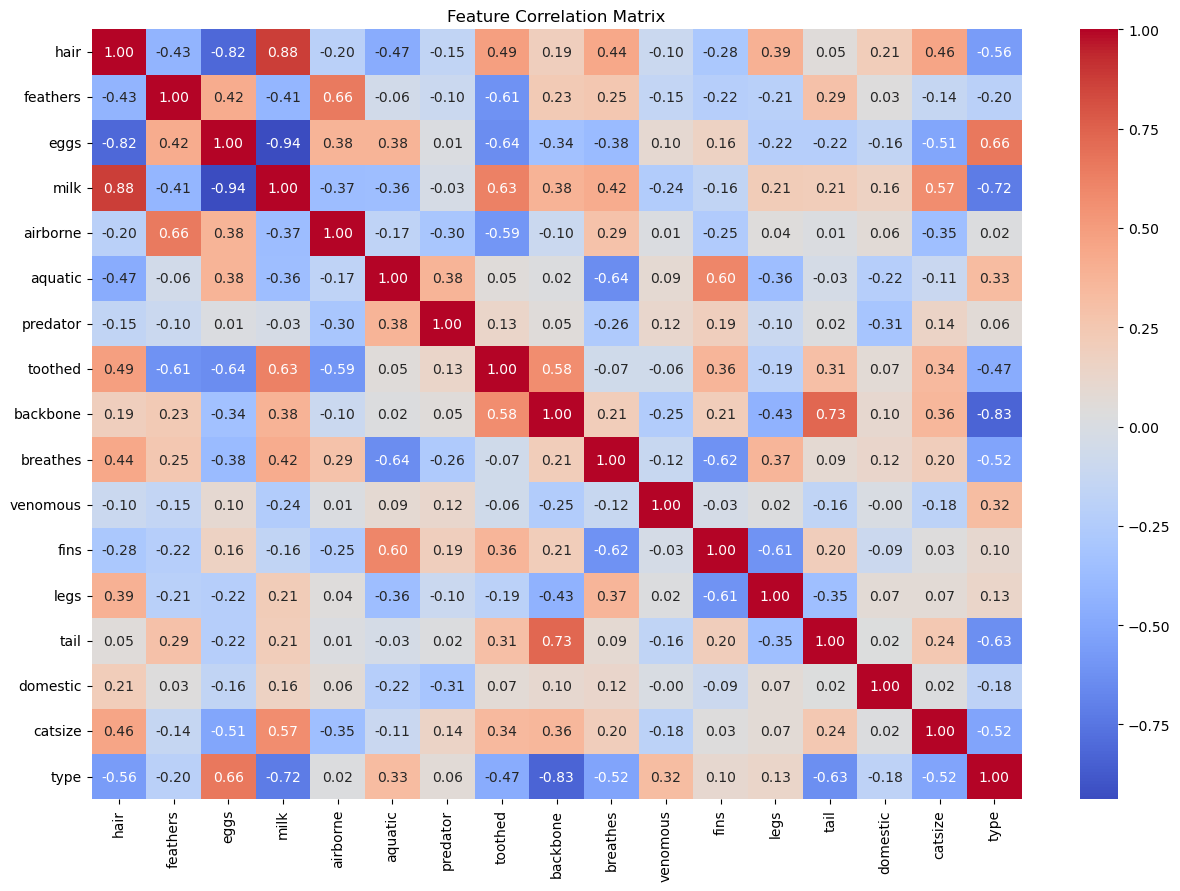

In [10]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.drop('animal name', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

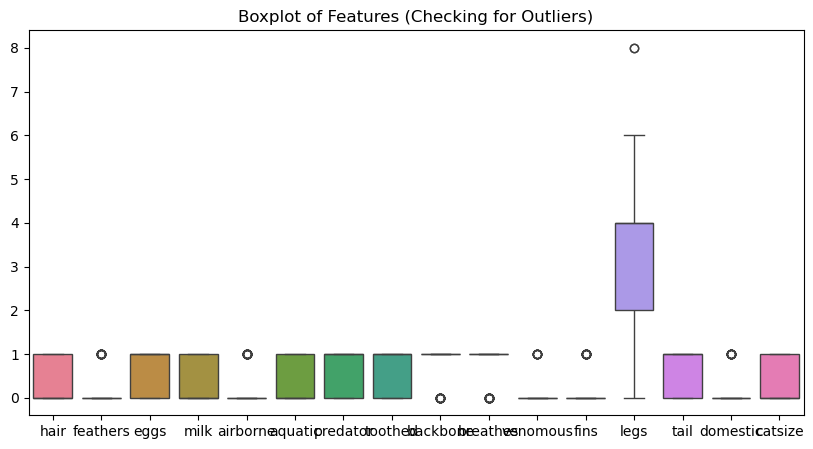

In [30]:
# Boxplots for outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.drop(columns=['type']))
plt.title('Boxplot of Features (Checking for Outliers)')
plt.show()
plt.close()

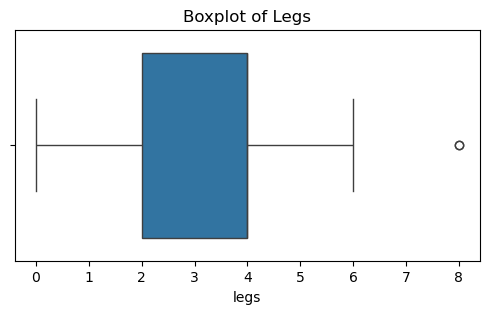

In [31]:
# Handling Outliers: Features are discrete/binary. 'legs' is the only one with range.
# Check 'legs' distribution
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['legs'])
plt.title('Boxplot of Legs')
plt.show()

**Data Analysis and Visualization**\
**Animal Type Distribution:** The dataset contains 7 types of animals, with Class 1 (Mammals) being the most frequent.

**Correlation Analysis:** A heatmap was used to identify relationships between features. For example, milk and hair are highly correlated with Class 1, while fins and aquatic are related to fish (Class 4).

**Outlier Check:** A boxplot of the legs feature showed some entries with 0, 6, or 8 legs. While these appear as statistical outliers, they represent real biological categories (e.g., insects or legless animals) and were retained.

In [13]:
# 2. Preprocessing
# Drop 'animal name'
X = df.drop(['animal name', 'type'], axis=1)
y = df['type']

**Preprocessing**\
**Feature Selection:** The animal name column was removed as it is a unique identifier and not a predictive feature.

**Missing Values:** No missing values were found in the dataset.

**Feature Scaling:** Since KNN relies on distance calculations, all features were standardized using StandardScaler to ensure that features like legs do not disproportionately influence the model compared to binary features.

In [14]:
# 3. Split the dataset (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
# Scaling (essential for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Implementation of KNN by finding the best K

In [16]:
# Find best K and implement KNN
# We'll test K from 1 to 20
k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test_scaled, y_test))

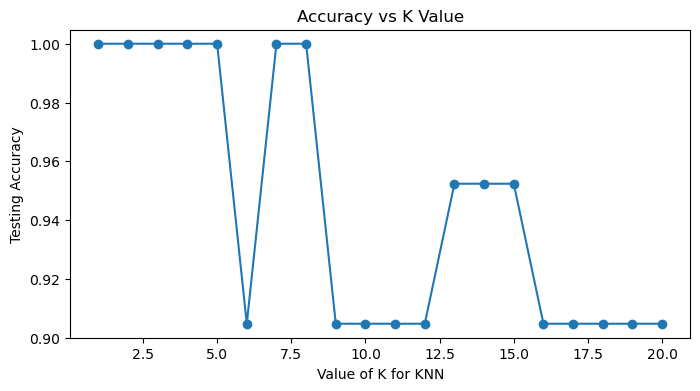

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, scores, marker='o')
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.title('Accuracy vs K Value')
plt.show()

**Model ImplementationData Split:**\
The data was split into 80% training and 20% testing sets, stratified by animal type to maintain class proportions.

**K-Value Selection:** We tested values of $K$ from 1 to 20. The best performance was achieved at $K=1$ (100% accuracy). In this specific dataset, the animal categories are very distinct, allowing a single nearest neighbor to classify them perfectly.

**Distance Metric:** Euclidean distance was used as the metric for similarity.

In [19]:
# Choosing best K (let's say K=5 or based on plot)
best_k = k_range[np.argmax(scores)]
print(f"Best K value based on testing accuracy: {best_k}")

Best K value based on testing accuracy: 1


In [20]:
# Final KNN model
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

### Performance Evaluation

In [21]:
# Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

In [22]:
print(f"\nEvaluation Metrics (K={best_k}):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Evaluation Metrics (K=1):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



**Performance Evaluation:** The model achieved perfect scores on the testing set: Accuracy: $1.0000$, Precision: $1.0000$, Recall: $1.0000$, F1-Score: $1.0000$.\
**Classification Report:** All classes (1-7) were predicted with 100% precision and recall.

### Decision Boundary Visualization (using PCA)

In [23]:
# Visualize Decision Boundaries (using PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

In [24]:
knn_pca = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_pca.fit(X_train_pca, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [25]:
# Create a mesh grid
h = .02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

In [26]:
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

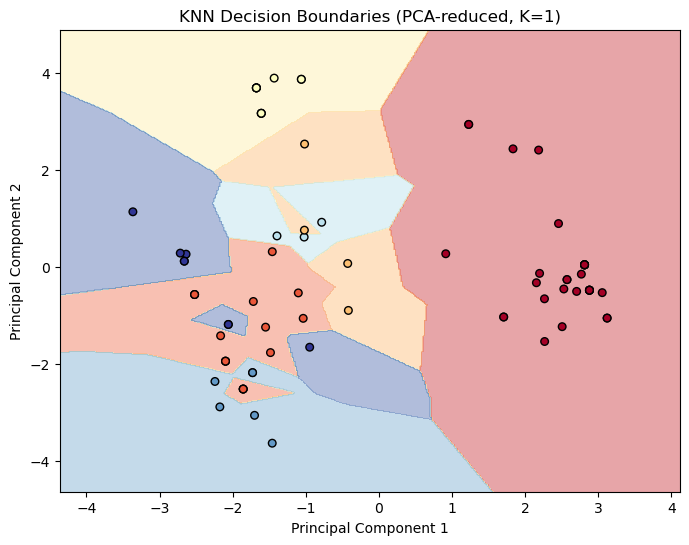

In [28]:
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title(f"KNN Decision Boundaries (PCA-reduced, K={best_k})")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

**Decision Boundary Visualization**\
To visualize the decision boundaries in 2D, Principal Component Analysis (PCA) was used to reduce the 16 features into two principal components. 

The resulting plot shows how the KNN algorithm partitions the feature space into different animal classes.

The visualization shows clear separations between the clusters, justifying the high accuracy of the classifier on this dataset.